# Conflict & Music Culture Analysis

This notebook analyzes how conflict (Ukraine/Russia, Israel, Palestine, Syria) affects music culture by tracking:
- Where artists are born
- Where they move (exile)
- If their popularity (Wikipedia Pageviews) spikes during war

## Setup & Imports

In [35]:
import requests
import pandas as pd
from urllib.parse import unquote, urlparse
import time
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import folium
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time


## Step 1: Wikidata Artist Extraction

Query Wikidata SPARQL endpoint for musicians (Q6396) born in:
- Ukraine (Q212)
- Russia (Q159)
- Israel (Q801)
- Palestine (Q219060)
- Syria (Q858)

In [36]:
# Wikidata SPARQL endpoint
WIKIDATA_ENDPOINT = "https://query.wikidata.org/sparql"

# Country codes for conflict regions
# Palestine uses citizenship (P27) instead of birth place due to disputed territories
COUNTRIES = {
    "Q212": "Ukraine",
    "Q159": "Russia",
    "Q801": "Israel",
    "Q858": "Syria"
}

# Palestine needs special handling - query by citizenship, not birth place
PALESTINE_ID = "Q219060"

def query_wikidata_musicians(country_id, country_name):
    """Query musicians by birth place country (P19 -> P17)"""
    query = f"""
    SELECT DISTINCT ?artist ?artistLabel ?birthPlaceLabel ?residenceLabel ?article
    WHERE {{
      ?artist wdt:P106/wdt:P279* wd:Q639669 .
      ?artist wdt:P19 ?birthPlace .
      ?birthPlace wdt:P17 wd:{country_id} .
      ?article schema:about ?artist .
      ?article schema:isPartOf <https://en.wikipedia.org/> .
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en" . }}
    }}
    LIMIT 500
    """
    return _execute_query(query, country_name)

def query_palestinian_musicians():
    """Query Palestinian musicians by citizenship (P27) - catches artists born in Jerusalem, West Bank, Gaza"""
    query = """
    SELECT DISTINCT ?artist ?artistLabel ?birthPlaceLabel ?residenceLabel ?article
    WHERE {
      ?artist wdt:P106/wdt:P279* wd:Q639669 .
      ?artist wdt:P27 wd:Q219060 .  # citizenship = State of Palestine
      OPTIONAL { ?artist wdt:P19 ?birthPlace . }
      ?article schema:about ?artist .
      ?article schema:isPartOf <https://en.wikipedia.org/> .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . }
    }
    LIMIT 500
    """
    return _execute_query(query, "Palestine")

def _execute_query(query, country_name):
    """Execute SPARQL query and return DataFrame"""
    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "CSS-Project-A/1.0 (Conflict Music Analysis; educational research)"
    }
    
    try:
        response = requests.get(
            WIKIDATA_ENDPOINT,
            params={"query": query},
            headers=headers,
            timeout=60
        )
        response.raise_for_status()
        data = response.json()
        
        results = []
        for item in data["results"]["bindings"]:
            artist_uri = item.get("artist", {}).get("value", "")
            wikidata_id = artist_uri.split("/")[-1] if artist_uri else ""
            
            results.append({
                "name": item.get("artistLabel", {}).get("value", ""),
                "wikidata_id": wikidata_id,
                "origin_country": country_name,
                "birth_place": item.get("birthPlaceLabel", {}).get("value", ""),
                "current_residence": item.get("residenceLabel", {}).get("value", ""),
                "wiki_url": item.get("article", {}).get("value", "")
            })
        
        return pd.DataFrame(results)
    
    except requests.exceptions.RequestException as e:
        print(f"Error querying Wikidata for {country_name}: {e}")
        return pd.DataFrame()

In [50]:
all_artists = []

# Query standard countries (by birth place)
for country_id, country_name in COUNTRIES.items():
    print(f"Querying {country_name} ({country_id})...")
    df = query_wikidata_musicians(country_id, country_name)
    print(f"  Found {len(df)} artists")
    all_artists.append(df)
    time.sleep(2)

# Query Palestine by citizenship (to catch Jerusalem, West Bank, Gaza)
print(f"Querying Palestine (by citizenship)...")
df_palestine = query_palestinian_musicians()
print(f"  Found {len(df_palestine)} artists")
all_artists.append(df_palestine)

# Combine all results
artists_df = pd.concat(all_artists, ignore_index=True)

# Remove duplicates
artists_df = artists_df.drop_duplicates(subset=["wikidata_id"])

print(f"\nTotal unique artists found: {len(artists_df)}")
artists_df.head(10)

Querying Ukraine (Q212)...
  Found 500 artists
Querying Russia (Q159)...
  Found 500 artists
Querying Israel (Q801)...
  Found 500 artists
Querying Syria (Q858)...
  Found 78 artists
Querying Palestine (by citizenship)...
  Found 31 artists

Total unique artists found: 1575


,name,wikidata_id,origin_country,birth_place,current_residence,wiki_url
0,Anna Fedorova,Q125885,Ukraine,Kyiv,,https://en.wikipedia.org/wiki/Anna_Fedorova
1,Ruslana Lyzhychko,Q129119,Ukraine,Lviv,,https://en.wikipedia.org/wiki/Ruslana
2,Sviatoslav Richter,Q124890,Ukraine,Zhytomyr,,https://en.wikipedia.org/wiki/Sviatoslav_Richter
3,Sergei Prokofiev,Q49481,Ukraine,Sontsivka,,https://en.wikipedia.org/wiki/Sergei_Prokofiev
4,Mykola Lysenko,Q172425,Ukraine,Hrynky,,https://en.wikipedia.org/wiki/Mykola_Lysenko
5,Samuel Maykapar,Q175282,Ukraine,Kherson,,https://en.wikipedia.org/wiki/Samuel_Maykapar
6,Moriz Rosenthal,Q213772,Ukraine,Lviv,,https://en.wikipedia.org/wiki/Moriz_Rosenthal
7,Norbert Glanzberg,Q213834,Ukraine,Rohatyn,,https://en.wikipedia.org/wiki/Norbert_Glanzberg
8,Vladimir Horowitz,Q192506,Ukraine,Kyiv,,https://en.wikipedia.org/wiki/Vladimir_Horowitz
9,Eduard Steuermann,Q214108,Ukraine,Sambir,,https://en.wikipedia.org/wiki/Eduard_Steuermann


## World Map Visualization TODO

Plot artists on a world map based on their birth place and current residence.

In [ ]:
# # Initialize geocoder with rate limiting
# geolocator = Nominatim(user_agent="css_project_music_analysis")
# geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# # Cache for geocoded locations to avoid repeated API calls
# location_cache = {}

# def get_coordinates(place_name):
#     """Get latitude and longitude for a place name."""
#     if not place_name or pd.isna(place_name) or place_name == "":
#         return None, None
    
#     # Check cache first
#     if place_name in location_cache:
#         return location_cache[place_name]
    
#     try:
#         location = geocode(place_name)
#         if location:
#             coords = (location.latitude, location.longitude)
#             location_cache[place_name] = coords
#             return coords
#         else:
#             location_cache[place_name] = (None, None)
#             return None, None
#     except Exception as e:
#         print(f"Error geocoding {place_name}: {e}")
#         location_cache[place_name] = (None, None)
#         return None, None

# print("Geocoding functions ready!")

Geocoding functions ready!


In [ ]:
# # Geocode birth places (this may take a while due to rate limiting)
# print("Geocoding birth places... This may take a few minutes.")

# # Get unique places to minimize API calls
# unique_birth_places = artists_df["birth_place"].dropna().unique()
# print(f"Found {len(unique_birth_places)} unique birth places to geocode.")

# # Geocode each unique place
# for i, place in enumerate(tqdm(unique_birth_places, desc="Geocoding")):
#     get_coordinates(place)
    
# print(f"\nGeocoded {len(location_cache)} locations.")

Geocoding birth places... This may take a few minutes.
Found 262 unique birth places to geocode.


Geocoding: 100%|██████████| 262/262 [04:21<00:00,  1.00it/s]


Geocoded 262 locations.


In [ ]:
# # Add coordinates to the dataframe
# artists_df["latitude"] = artists_df["birth_place"].apply(lambda x: get_coordinates(x)[0] if x else None)
# artists_df["longitude"] = artists_df["birth_place"].apply(lambda x: get_coordinates(x)[1] if x else None)

# # Check how many artists have valid coordinates
# valid_coords = artists_df.dropna(subset=["latitude", "longitude"])
# print(f"Artists with valid coordinates: {len(valid_coords)} out of {len(artists_df)}")

Artists with valid coordinates: 1169 out of 1183


In [ ]:
# # Create an interactive world map
# # Center the map on Europe/Middle East region
# world_map = folium.Map(location=[40, 40], zoom_start=3, tiles="CartoDB positron")

# # Color mapping for countries
# country_colors = {
#     "Ukraine": "blue",
#     "Russia": "red",
#     "Iran": "green",
#     "Palestine": "orange",
#     "Syria": "purple"
# }

# # Add markers for each artist
# for idx, row in valid_coords.iterrows():
#     color = country_colors.get(row["origin_country"], "gray")
    
#     # Create popup with artist info
#     popup_html = f"""
#     <b>{row['name']}</b><br>
#     Country: {row['origin_country']}<br>
#     Birth Place: {row['birth_place']}<br>
#     <a href="{row['wiki_url']}" target="_blank">Wikipedia</a>
#     """
    
#     folium.CircleMarker(
#         location=[row["latitude"], row["longitude"]],
#         radius=6,
#         color=color,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=300),
#         tooltip=row["name"]
#     ).add_to(world_map)

# # Add a legend
# legend_html = """
# <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
#             background-color: white; padding: 10px; border: 2px solid gray; border-radius: 5px;">
#     <b>Origin Country</b><br>
#     <i style="background: blue; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Ukraine<br>
#     <i style="background: red; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Russia<br>
#     <i style="background: green; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Iran<br>
#     <i style="background: orange; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Palestine<br>
#     <i style="background: purple; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Syria
# </div>
# """
# world_map.get_root().html.add_child(folium.Element(legend_html))

# print("Interactive map created! Click on markers for artist details.")
# world_map

Interactive map created! Click on markers for artist details.


In [ ]:
# # Save the map as an HTML file (can be opened in any browser)
# world_map.save("artists_world_map.html")
# print("Map saved to: artists_world_map.html")

Map saved to: artists_world_map.html


## Current Residence Problem

The `P551` (residence) property gives only a few 'current_residence' for the aritsts, maybe 5 %. Looking more into, there is an assumption that the artists' residence is based on the following:
- **P937**: Work location
- **P27**: Country of citizenship  
- **P69**: Educated at (location)

In [51]:
def enrich_artist_locations(wikidata_ids):
    # Batches - avoiding time outs
    batch_size = 50
    all_results = []
    
    for i in range(0, len(wikidata_ids), batch_size):
        batch = wikidata_ids[i:i+batch_size]
        ids_str = " ".join([f"wd:{wid}" for wid in batch])
        
        query = f"""
        SELECT DISTINCT ?artist ?residenceLabel ?workLocationLabel ?citizenshipLabel ?educatedAtLocationLabel
        WHERE {{
          VALUES ?artist {{ {ids_str} }}
          
          # Residence (P551)
          OPTIONAL {{ ?artist wdt:P551 ?residence . }}
          
          # Work location (P937)
          OPTIONAL {{ ?artist wdt:P937 ?workLocation . }}
          
          # Country of citizenship (P27)
          OPTIONAL {{ ?artist wdt:P27 ?citizenship . }}
          
          # Educated at -> location (P69 -> P131/P17)
          OPTIONAL {{ 
            ?artist wdt:P69 ?school .
            ?school wdt:P131*/wdt:P17? ?educatedAtLocation .
            FILTER(EXISTS {{ ?educatedAtLocation wdt:P31/wdt:P279* wd:Q6256 }} || 
                   EXISTS {{ ?educatedAtLocation wdt:P31/wdt:P279* wd:Q515 }})
          }}
          
          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en" . }}
        }}
        """
        
        headers = {
            "Accept": "application/sparql-results+json",
            "User-Agent": "CSS-Project-A/1.0 (educational research)"
        }
        
        try:
            response = requests.get(
                WIKIDATA_ENDPOINT,
                params={"query": query},
                headers=headers,
                timeout=60
            )
            response.raise_for_status()
            data = response.json()
            
            for item in data["results"]["bindings"]:
                artist_uri = item.get("artist", {}).get("value", "")
                wid = artist_uri.split("/")[-1] if artist_uri else ""
                
                all_results.append({
                    "wikidata_id": wid,
                    "residence": item.get("residenceLabel", {}).get("value", ""),
                    "work_location": item.get("workLocationLabel", {}).get("value", ""),
                    "citizenship": item.get("citizenshipLabel", {}).get("value", ""),
                    "educated_at_location": item.get("educatedAtLocationLabel", {}).get("value", "")
                })
                
        except Exception as e:
            print(f"Error in batch {i//batch_size + 1}: {e}")
        
        time.sleep(1)  # Rate limiting
        print(f"Processed batch {i//batch_size + 1}/{(len(wikidata_ids) + batch_size - 1)//batch_size}")
    
    return pd.DataFrame(all_results)

In [52]:
# Enrich location data and fill current_residence with hierarchy residence > work_location > citizenship > educated_at > birth_place
wikidata_ids = artists_df["wikidata_id"].tolist()
enriched_df = enrich_artist_locations(wikidata_ids)

# Aggregate per artist
enriched_agg = enriched_df.groupby("wikidata_id").agg({
    "residence": lambda x: "; ".join(sorted(set(filter(None, x)))),
    "work_location": lambda x: "; ".join(sorted(set(filter(None, x)))),
    "citizenship": lambda x: "; ".join(sorted(set(filter(None, x)))),
    "educated_at_location": lambda x: "; ".join(sorted(set(filter(None, x))))
}).reset_index()

# Count BEFORE enrichment 
before = (artists_df["current_residence"].notna() & (artists_df["current_residence"] != "")).sum()

# Merge enriched data
artists_df = artists_df.merge(enriched_agg, on="wikidata_id", how="left", suffixes=("", "_enriched"))

# Fill current_residence using simple hierarchy: residence > work_location > citizenship > educated_at > birth_place
for idx, row in artists_df.iterrows():
    if row.get("residence") and pd.notna(row["residence"]):
        artists_df.at[idx, "current_residence"] = row["residence"].split(";")[0].strip()
    elif row.get("current_residence") and pd.notna(row["current_residence"]):
        pass  # keep original
    elif row.get("work_location") and pd.notna(row["work_location"]):
        artists_df.at[idx, "current_residence"] = row["work_location"].split(";")[0].strip()
    elif row.get("citizenship") and pd.notna(row["citizenship"]):
        artists_df.at[idx, "current_residence"] = row["citizenship"].split(";")[0].strip()
    elif row.get("educated_at_location") and pd.notna(row["educated_at_location"]):
        artists_df.at[idx, "current_residence"] = row["educated_at_location"].split(";")[0].strip()
    else:
        artists_df.at[idx, "current_residence"] = row.get("birth_place", "")

# Count AFTER enrichment
after = (artists_df["current_residence"].notna() & (artists_df["current_residence"] != "")).sum()
print(f"BEFORE (P551 only): {before} artists")
print(f"AFTER (with hierarchy): {after} artists")
print(f"Improvement: +{after - before} artists")

Processed batch 1/32
Processed batch 2/32
Processed batch 3/32
Processed batch 4/32
Processed batch 5/32
Processed batch 6/32
Processed batch 7/32
Processed batch 8/32
Processed batch 9/32
Processed batch 10/32
Processed batch 11/32
Processed batch 12/32
Processed batch 13/32
Processed batch 14/32
Processed batch 15/32
Processed batch 16/32
Processed batch 17/32
Processed batch 18/32
Processed batch 19/32
Processed batch 20/32
Processed batch 21/32
Processed batch 22/32
Processed batch 23/32
Processed batch 24/32
Processed batch 25/32
Processed batch 26/32
Processed batch 27/32
Processed batch 28/32
Processed batch 29/32
Processed batch 30/32
Processed batch 31/32
Processed batch 32/32
BEFORE (P551 only): 0 artists
AFTER (with hierarchy): 1575 artists
Improvement: +1575 artists


In [53]:
# Save artists_df to CSV
core_columns = ["name", "wikidata_id", "origin_country", "birth_place", "current_residence", "wiki_url"]
artists_df[core_columns].to_csv("artists_data.csv", index=False, encoding="utf-8")
print(f"Saved {len(artists_df)} artists to artists_data.csv")

Saved 1575 artists to artists_data.csv


## Wikipedia Pageviews Collection: Do artists loose or gain listeners during the war?

Collect monthly pageviews for each artist from January 2021 to December 2023 using the Wikipedia Pageviews API.

In [54]:
# Conflict start dates for analysis
CONFLICT_DATES = {
    "Ukraine": "2022-02-24",      # Russian invasion
    "Russia": "2022-02-24",       # Same event (aggressor side)
    "Syria": "2011-03-15",        # Civil war start
    "Israel": "2023-10-07",       # Gaza war (Israeli side)
    "Palestine": "2023-10-07"     # Gaza war (Palestinian side)
}

def extract_wiki_title(wiki_url):
    """Extract the Wikipedia article title from the URL."""
    if not wiki_url:
        return None
    try:
        parsed = urlparse(wiki_url)
        path = parsed.path
        if path.startswith("/wiki/"):
            title = path[6:]
        else:
            title = path.split("/")[-1]
        return unquote(title)
    except:
        return None

# Get Montly page views
def get_monthly_pageviews(article_title, start_date="20210101", end_date="20231231"):
    if not article_title:
        return {"monthly": {}, "total": 0}
    
    base_url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article"
    encoded_title = requests.utils.quote(article_title.replace(" ", "_"), safe="")
    url = f"{base_url}/en.wikipedia/all-access/all-agents/{encoded_title}/monthly/{start_date}/{end_date}"
    
    headers = {
        "User-Agent": "CSS-Project-A/1.0 (Conflict Music Analysis; educational research)"
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=30)
        if response.status_code == 200:
            data = response.json()
            monthly = {}
            total = 0
            for item in data.get("items", []):
                # Format: 2021010100 -> 2021-01
                ts = item["timestamp"]
                month_key = f"{ts[:4]}-{ts[4:6]}"
                monthly[month_key] = item["views"]
                total += item["views"]
            return {"monthly": monthly, "total": total}
        else:
            return {"monthly": {}, "total": 0}
    except:
        return {"monthly": {}, "total": 0}

def get_pageviews(article_title, start_date="20210101", end_date="20231231"):
    return get_monthly_pageviews(article_title, start_date, end_date)["total"]

In [55]:
# Extract article titles from URLs
artists_df["wiki_title"] = artists_df["wiki_url"].apply(extract_wiki_title)

# Preview
print("Sample wiki titles:")
artists_df[["name", "wiki_url", "wiki_title"]].head()

Sample wiki titles:


,name,wiki_url,wiki_title
0,Anna Fedorova,https://en.wikipedia.org/wiki/Anna_Fedorova,Anna_Fedorova
1,Ruslana Lyzhychko,https://en.wikipedia.org/wiki/Ruslana,Ruslana
2,Sviatoslav Richter,https://en.wikipedia.org/wiki/Sviatoslav_Richter,Sviatoslav_Richter
3,Sergei Prokofiev,https://en.wikipedia.org/wiki/Sergei_Prokofiev,Sergei_Prokofiev
4,Mykola Lysenko,https://en.wikipedia.org/wiki/Mykola_Lysenko,Mykola_Lysenko


In [57]:
# Collect monthly pageviews for all artists
print("Collecting monthly Wikipedia pageviews (Jan 2021 - Dec 2023)...")
print("This may take several minutes due to API rate limiting.\n")

all_monthly_data = []
errors = 0

for idx, row in tqdm(artists_df.iterrows(), total=len(artists_df), desc="Fetching pageviews"):
    title = row["wiki_title"]
    result = get_monthly_pageviews(title)
    
    # Store monthly data with artist info
    for month, views in result["monthly"].items():
        all_monthly_data.append({
            "wikidata_id": row["wikidata_id"],
            "name": row["name"],
            "origin_country": row["origin_country"],
            "month": month,
            "views": views
        })
    
    if result["total"] == 0:
        errors += 1
    
    time.sleep(0.1)

# Create monthly pageviews DataFrame
monthly_df = pd.DataFrame(all_monthly_data)

# Also add total to artists_df
artists_df["views_2021_to_2023"] = artists_df["wiki_title"].apply(
    lambda t: get_monthly_pageviews(t)["total"] if pd.notna(t) else 0
)

print(f"\nCompleted! {errors} artists had no pageview data.")
print(f"Monthly records: {len(monthly_df)}")
monthly_df.head()

This may take several minutes due to API rate limiting.



Fetching pageviews: 100%|██████████| 1575/1575 [07:46<00:00,  3.38it/s]



Completed! 1275 artists had no pageview data.
Monthly records: 10350


,wikidata_id,name,origin_country,month,views
0,Q107449,Pavel Gililov,Ukraine,2021-08,158
1,Q107449,Pavel Gililov,Ukraine,2021-09,164
2,Q107449,Pavel Gililov,Ukraine,2021-10,871
3,Q107449,Pavel Gililov,Ukraine,2021-11,347
4,Q107449,Pavel Gililov,Ukraine,2021-12,324


In [46]:
# Analyze before vs after conflict for each country
print("Pageviews BEFORE vs AFTER conflict:\n")

for country, conflict_date in CONFLICT_DATES.items():
    country_data = monthly_df[monthly_df["origin_country"] == country].copy()
    
    if len(country_data) == 0:
        print(f"{country}: No data")
        continue
    
    conflict_month = conflict_date[:7]  # e.g., "2022-02"
    
    before = country_data[country_data["month"] < conflict_month]["views"].sum()
    after = country_data[country_data["month"] >= conflict_month]["views"].sum()
    
    # Calculate months for average
    months_before = len(country_data[country_data["month"] < conflict_month]["month"].unique())
    months_after = len(country_data[country_data["month"] >= conflict_month]["month"].unique())
    
    avg_before = before / months_before if months_before > 0 else 0
    avg_after = after / months_after if months_after > 0 else 0
    
    change_pct = ((avg_after - avg_before) / avg_before * 100) if avg_before > 0 else 0
    
    print(f"{country} (conflict: {conflict_date}):")
    print(f"  BEFORE: {before:,} total ({months_before} months, avg {avg_before:,.0f}/month)")
    print(f"  AFTER:  {after:,} total ({months_after} months, avg {avg_after:,.0f}/month)")
    print(f"  Change: {change_pct:+.1f}%")
    print()

Pageviews BEFORE vs AFTER conflict:

Ukraine: No data
Russia (conflict: 2022-02-24):
  BEFORE: 9,087,805 total (13 months, avg 699,062/month)
  AFTER:  17,154,556 total (23 months, avg 745,850/month)
  Change: +6.7%

Syria: No data
Israel: No data
Palestine: No data


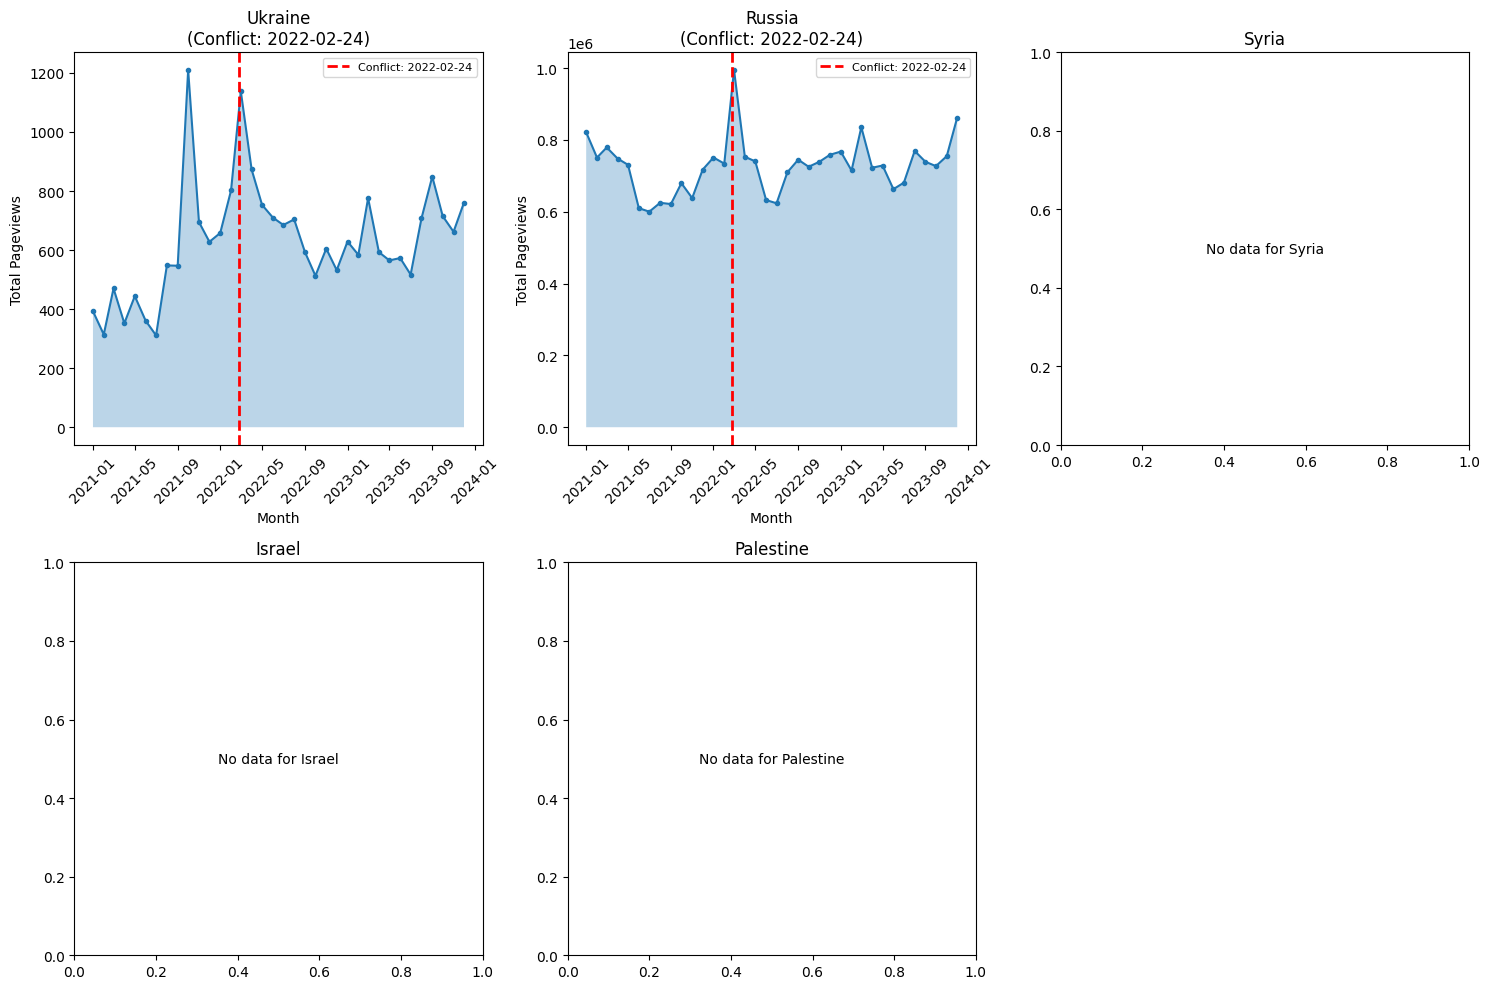

Visualization saved to: pageviews_by_conflict.png


In [58]:
# Visualize monthly pageview trends by country with conflict markers
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (country, conflict_date) in enumerate(CONFLICT_DATES.items()):
    if i >= len(axes):
        break
        
    ax = axes[i]
    country_data = monthly_df[monthly_df["origin_country"] == country].copy()
    
    if len(country_data) == 0:
        ax.text(0.5, 0.5, f"No data for {country}", ha='center', va='center')
        ax.set_title(country)
        continue
    
    # Aggregate by month
    monthly_totals = country_data.groupby("month")["views"].sum().sort_index()
    
    # Convert to datetime for plotting
    dates = [datetime.strptime(m, "%Y-%m") for m in monthly_totals.index]
    views = monthly_totals.values
    
    ax.plot(dates, views, marker='o', markersize=3, linewidth=1.5)
    ax.fill_between(dates, views, alpha=0.3)
    
    # Add conflict marker
    conflict_dt = datetime.strptime(conflict_date, "%Y-%m-%d")
    ax.axvline(x=conflict_dt, color='red', linestyle='--', linewidth=2, label=f'Conflict: {conflict_date}')
    
    ax.set_title(f"{country}\n(Conflict: {conflict_date})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Pageviews")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

# Hide unused subplot
if len(CONFLICT_DATES) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig("pageviews_by_conflict.png", dpi=150, bbox_inches="tight")
plt.show()

print("Visualization saved to: pageviews_by_conflict.png")

In [ ]:
# Save monthly pageviews data for detailed analysis
# monthly_df.to_csv("monthly_pageviews.csv", index=False)